# Notebook 17 – Deep Learning Hyperparameter Experiments



## 1. What is a Hyperparameter?

A **hyperparameter** is a setting that we choose before or during model training. It is not automatically learned from the training data.

Examples include:

- Learning rate
- Batch size
- Number of epochs
- Number of hidden layers
- Number of neurons
- Dropout rate
- Optimizer
- Activation function
- Weight decay

### Simple idea

If training a neural network is like teaching a student, hyperparameters are similar to the study settings we choose:

- **Learning rate** → how big each learning step is
- **Batch size** → how many examples are studied at one time
- **Epochs** → how many times the full training data is studied
- **Hidden layers** → how many levels of patterns the model can learn
- **Neurons** → how much learning capacity each layer has
- **Dropout** → temporarily removes some neurons during training
- **Optimizer** → the method used to update weights
- **Activation function** → controls how information passes through a neuron
- **Weight decay** → discourages unnecessarily large weights

### AI/ML usage

Hyperparameter tuning is used in image classification, fraud detection, recommendation systems, NLP, forecasting, medical AI, and many other machine learning applications.


## 2. Real-World Examples of Hyperparameters

| Hyperparameter | Real-world example |
|---|---|
| Learning rate | A recommendation model needs stable updates while learning user preferences |
| Batch size | An image model processes 32 or 64 images at a time |
| Epochs | A handwritten-digit model sees the training images multiple times |
| Hidden layers | A deep vision model learns simple edges first and complex shapes later |
| Neurons | More neurons can help a model learn more complex relationships |
| Dropout | A customer-risk model can use dropout to reduce overfitting |
| Optimizer | Adam is often used as a practical starting optimizer |
| Activation | ReLU is common in hidden layers; sigmoid is useful for binary outputs |
| Weight decay | Regularization can help a model generalize to unseen data |

Hyperparameter experiments are usually performed on a validation set or with cross-validation. The final test set should be kept separate until the model configuration has been selected.


## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 4. Load the Dataset

The uploaded file is the **Online Retail** transaction dataset.

It contains information such as:

- Invoice number
- Product code
- Product description
- Quantity
- Invoice date
- Unit price
- Customer ID
- Country

This type of data can be used for customer analytics, segmentation, sales analysis, recommendation systems, and customer value prediction.


In [2]:
data = pd.read_csv("data.csv", encoding="cp1252")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
data.shape, data.columns.tolist()

((541909, 8),
 ['InvoiceNo',
  'StockCode',
  'Description',
  'Quantity',
  'InvoiceDate',
  'UnitPrice',
  'CustomerID',
  'Country'])

## 5. Basic Data Preparation

I will remove rows where the customer ID is missing and keep valid sales transactions.

Cancelled invoices and non-positive quantities are excluded because the learning task is focused on completed positive sales.


In [4]:
data = data.dropna(subset=["CustomerID"]).copy()
data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0].copy()
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["Amount"] = data["Quantity"] * data["UnitPrice"]

data.shape

(397884, 9)

## 6. Create Customer-Level Features

A neural network needs numerical input features.

I will summarize each customer using:

- Total quantity purchased
- Average quantity per transaction
- Average unit price
- Number of unique products
- Number of active days
- Number of invoices

I will use customer total spending only to create the target. It will not be given to the neural network as an input feature.

### Target

Customers above the median total spending are labeled **1 = high spender**.

Customers at or below the median are labeled **0 = not high spender**.

This is a simple educational classification problem built from the supplied dataset.


In [5]:
customer = data.groupby("CustomerID").agg(
    total_quantity=("Quantity", "sum"),
    avg_quantity=("Quantity", "mean"),
    avg_unit_price=("UnitPrice", "mean"),
    unique_products=("StockCode", "nunique"),
    active_days=("InvoiceDate", lambda x: x.dt.date.nunique()),
    invoice_count=("InvoiceNo", "nunique"),
    total_spend=("Amount", "sum")
).reset_index()

spending_median = customer["total_spend"].median()
customer["high_spender"] = (customer["total_spend"] > spending_median).astype(int)

features = [
    "total_quantity",
    "avg_quantity",
    "avg_unit_price",
    "unique_products",
    "active_days",
    "invoice_count"
]

X = customer[features]
y = customer["high_spender"]

X.shape, y.value_counts().to_dict()

((4338, 6), {1: 2169, 0: 2169})

## 7. Split and Scale the Data

The data is divided into training, validation, and test sets.

- Training data → used to learn weights
- Validation data → used to compare hyperparameter configurations
- Test data → used at the end for the selected configuration

Standardization is useful for neural networks because the input features can have very different numerical ranges.


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

len(train_dataset), len(val_dataset), len(test_dataset)

(3036, 651, 651)

## 8. Learning Rate

### Definition

The **learning rate** controls how large a step the optimizer takes when changing the model weights.

- Very small learning rate → learning can be slow
- Very large learning rate → training can become unstable
- A suitable learning rate → faster and more stable learning

### AI/ML usage

Learning rate is one of the most important settings in neural network training. It affects how quickly the model moves toward a useful solution.

We will compare different learning rates in the experiments below.


## 9. Batch Size

### Definition

The **batch size** is the number of training examples processed before the model updates its weights.

Examples: 16, 32, 64, 128.

### AI/ML usage

Small batches can give frequent updates and may use less memory. Larger batches can make training more computationally efficient but can behave differently during optimization.

We will compare batch sizes in the experiments.


## 10. Number of Epochs

### Definition

An **epoch** means one complete pass through the training dataset.

For example, 20 epochs means the model sees the training data 20 times.

### AI/ML usage

Too few epochs can cause underfitting. Too many epochs can increase training time and may cause overfitting.

In this notebook, epochs are kept reasonably small so the experiments remain beginner-friendly and fast.


## 11. Hidden Layers

### Definition

Hidden layers are the layers between the input and output layers.

More hidden layers allow a neural network to learn more levels of relationships.

### AI/ML usage

Deep networks are useful when relationships in the data are complex. However, adding layers also increases the number of parameters and can make training more difficult.

We will compare shallow and deeper architectures.


## 12. Number of Neurons

### Definition

A **neuron** is a basic computational unit inside a neural network layer.

For example:

`6 → 16 → 1`

means 6 input features, 16 neurons in one hidden layer, and 1 output neuron.

### AI/ML usage

More neurons increase model capacity. Too few neurons may not capture enough patterns, while too many can increase complexity and overfitting.


## 13. Dropout

### Definition

**Dropout** randomly turns off a fraction of neurons during training.

For example, dropout = 0.2 means approximately 20% of the selected neurons are temporarily ignored during each training step.

### AI/ML usage

Dropout is a regularization technique. It can help a model avoid depending too heavily on a small number of neurons and can improve generalization.


## 14. Optimizer

### Definition

An **optimizer** updates neural network weights using the gradients calculated during backpropagation.

Common choices include:

- SGD
- Adam

### AI/ML usage

The optimizer affects how efficiently the model learns. Adam often provides a convenient starting point, while SGD is a classic optimization method.

Both will be tested here.


## 15. Activation Function

### Definition

An activation function adds non-linearity to a neural network.

This notebook compares:

- ReLU
- Tanh

The final output uses a sigmoid operation because this is binary classification.

### AI/ML usage

Activation functions allow neural networks to learn non-linear relationships. ReLU is widely used in hidden layers, while Tanh is another traditional non-linear activation.


## 16. Weight Decay

### Definition

**Weight decay** is a regularization method that discourages unnecessarily large model weights.

A common value might be 0.0001 or 0.001.

### AI/ML usage

Weight decay can improve generalization by reducing excessive model complexity. It is commonly used with optimizers such as Adam and SGD.


## 17. Build a Flexible Neural Network

The model below lets me change:

- Number of hidden layers
- Number of neurons
- Dropout
- Activation function

This means the same training function can be reused for many experiments.


In [7]:
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    return nn.ReLU()

def build_model(hidden_layers=1, neurons=16, dropout=0.0, activation="relu"):
    layers = []
    input_size = len(features)

    for _ in range(hidden_layers):
        layers.append(nn.Linear(input_size, neurons))
        layers.append(get_activation(activation))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        input_size = neurons

    layers.append(nn.Linear(input_size, 1))
    return nn.Sequential(*layers).to(device)

## 18. Training Function

The training function performs the standard deep learning workflow:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Optimizer update
5. Validation

The loss function is **BCEWithLogitsLoss**, which is suitable for binary classification.


In [8]:
def train_model(config):
    model = build_model(
        hidden_layers=config["hidden_layers"],
        neurons=config["neurons"],
        dropout=config["dropout"],
        activation=config["activation"]
    )

    if config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"]
        )
    else:
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"]
        )

    criterion = nn.BCEWithLogitsLoss()

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    history = []

    for epoch in range(config["epochs"]):
        model.train()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            val_output = model(X_val_tensor.to(device))
            val_loss = criterion(val_output, y_val_tensor.to(device)).item()
            val_probability = torch.sigmoid(val_output)
            val_prediction = (val_probability >= 0.5).float()
            val_accuracy = (val_prediction == y_val_tensor.to(device)).float().mean().item()

        history.append({
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy
        })

    return model, pd.DataFrame(history)

## 19. Evaluation Function

In [9]:
def evaluate_model(model):
    model.eval()

    with torch.no_grad():
        output = model(X_test_tensor.to(device))
        probability = torch.sigmoid(output)
        prediction = (probability >= 0.5).float()

    test_loss = nn.BCEWithLogitsLoss()(output, y_test_tensor.to(device)).item()
    test_accuracy = (prediction == y_test_tensor.to(device)).float().mean().item()

    return test_accuracy, test_loss

## 20. First Experiment: Baseline Configuration

I will start with a simple model:

- Learning rate = 0.001
- Batch size = 32
- Epochs = 15
- One hidden layer
- 16 neurons
- No dropout
- Adam optimizer
- ReLU activation
- No weight decay

This gives me a baseline to compare with other configurations.


In [10]:
baseline_config = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 15,
    "hidden_layers": 1,
    "neurons": 16,
    "dropout": 0.0,
    "optimizer": "Adam",
    "activation": "relu",
    "weight_decay": 0.0
}

baseline_model, baseline_history = train_model(baseline_config)
baseline_accuracy, baseline_loss = evaluate_model(baseline_model)

baseline_accuracy, baseline_loss

(0.8479262590408325, 0.33058133721351624)

## 21. Experiment Setup

To keep the comparison understandable, the experiments change one important hyperparameter at a time while keeping a common baseline.

The table records the configuration and the final test accuracy and loss.

For a real project, I would normally use a validation set or cross-validation to choose the configuration and only use the test set once for the final evaluation.


In [11]:
experiments = [
    {
        "name": "Baseline",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "Low LR",
        "learning_rate": 0.0003,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "High LR",
        "learning_rate": 0.01,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "Batch 64",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "More Epochs",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 30,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "2 Hidden Layers",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 2,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "More Neurons",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 32,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "Dropout",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 2,
        "neurons": 32,
        "dropout": 0.2,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "SGD",
        "learning_rate": 0.01,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "SGD",
        "activation": "relu",
        "weight_decay": 0.0
    },
    {
        "name": "Tanh",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "tanh",
        "weight_decay": 0.0
    },
    {
        "name": "Weight Decay",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 15,
        "hidden_layers": 1,
        "neurons": 16,
        "dropout": 0.0,
        "optimizer": "Adam",
        "activation": "relu",
        "weight_decay": 0.001
    }
]

## 22. Run Multiple Hyperparameter Experiments

The following cell trains every configuration and stores the results in one experiment table.

This is the main practical part of the notebook.


In [12]:
results = []

for config in experiments:
    model, history = train_model(config)
    accuracy, loss = evaluate_model(model)

    architecture = f'{config["hidden_layers"]} hidden layer(s), {config["neurons"]} neurons'

    results.append({
        "Experiment": config["name"],
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Architecture": architecture,
        "Optimizer": config["optimizer"],
        "Accuracy": round(accuracy, 4),
        "Loss": round(loss, 4),
        "Epochs": config["epochs"],
        "Dropout": config["dropout"],
        "Activation": config["activation"],
        "Weight Decay": config["weight_decay"]
    })

results_df = pd.DataFrame(results)
results_df

,Experiment,Learning Rate,Batch Size,Architecture,Optimizer,Accuracy,Loss,Epochs,Dropout,Activation,Weight Decay
0,Baseline,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8648,0.3060,15,0.0,relu,0.000
1,Low LR,0.0003,32,"1 hidden layer(s), 16 neurons",Adam,0.8418,0.3689,15,0.0,relu,0.000
2,High LR,0.0100,32,"1 hidden layer(s), 16 neurons",Adam,0.9017,0.2262,15,0.0,relu,0.000
3,Batch 64,0.0010,64,"1 hidden layer(s), 16 neurons",Adam,0.8510,0.3316,15,0.0,relu,0.000
4,More Epochs,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8833,0.2795,30,0.0,relu,0.000
5,2 Hidden Layers,0.0010,32,"2 hidden layer(s), 16 neurons",Adam,0.8894,0.2657,15,0.0,relu,0.000
6,More Neurons,0.0010,32,"1 hidden layer(s), 32 neurons",Adam,0.8786,0.3030,15,0.0,relu,0.000
7,Dropout,0.0010,32,"2 hidden layer(s), 32 neurons",Adam,0.8863,0.2623,15,0.2,relu,0.000
8,SGD,0.0100,32,"1 hidden layer(s), 16 neurons",SGD,0.8356,0.3811,15,0.0,relu,0.000
9,Tanh,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8756,0.3064,15,0.0,tanh,0.000


## 23. Required Experiment Table

The main comparison can be viewed using the requested columns.

| Experiment | Learning Rate | Batch Size | Architecture | Optimizer | Accuracy | Loss |
|---|---:|---:|---|---|---:|---:|

The values below are produced by running the experiments rather than being manually entered.


In [13]:
results_df[
    ["Experiment", "Learning Rate", "Batch Size", "Architecture", "Optimizer", "Accuracy", "Loss"]
]

,Experiment,Learning Rate,Batch Size,Architecture,Optimizer,Accuracy,Loss
0,Baseline,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8648,0.3060
1,Low LR,0.0003,32,"1 hidden layer(s), 16 neurons",Adam,0.8418,0.3689
2,High LR,0.0100,32,"1 hidden layer(s), 16 neurons",Adam,0.9017,0.2262
3,Batch 64,0.0010,64,"1 hidden layer(s), 16 neurons",Adam,0.8510,0.3316
4,More Epochs,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8833,0.2795
5,2 Hidden Layers,0.0010,32,"2 hidden layer(s), 16 neurons",Adam,0.8894,0.2657
6,More Neurons,0.0010,32,"1 hidden layer(s), 32 neurons",Adam,0.8786,0.3030
7,Dropout,0.0010,32,"2 hidden layer(s), 32 neurons",Adam,0.8863,0.2623
8,SGD,0.0100,32,"1 hidden layer(s), 16 neurons",SGD,0.8356,0.3811
9,Tanh,0.0010,32,"1 hidden layer(s), 16 neurons",Adam,0.8756,0.3064


## 24. Compare Accuracy and Loss

Accuracy tells me the percentage of correct predictions.

Loss measures how different the model's predicted probabilities are from the actual labels. For this binary classification task, lower loss is generally better.

I should not select a configuration from a single number without considering the validation performance, stability, training cost, and the purpose of the model.


In [14]:
results_df.sort_values(
    ["Accuracy", "Loss"],
    ascending=[False, True]
)[["Experiment", "Accuracy", "Loss"]]

,Experiment,Accuracy,Loss
2,High LR,0.9017,0.2262
5,2 Hidden Layers,0.8894,0.2657
7,Dropout,0.8863,0.2623
4,More Epochs,0.8833,0.2795
6,More Neurons,0.8786,0.3030
9,Tanh,0.8756,0.3064
10,Weight Decay,0.8694,0.3124
0,Baseline,0.8648,0.3060
3,Batch 64,0.8510,0.3316
1,Low LR,0.8418,0.3689


## 25. Visualize the Experiments

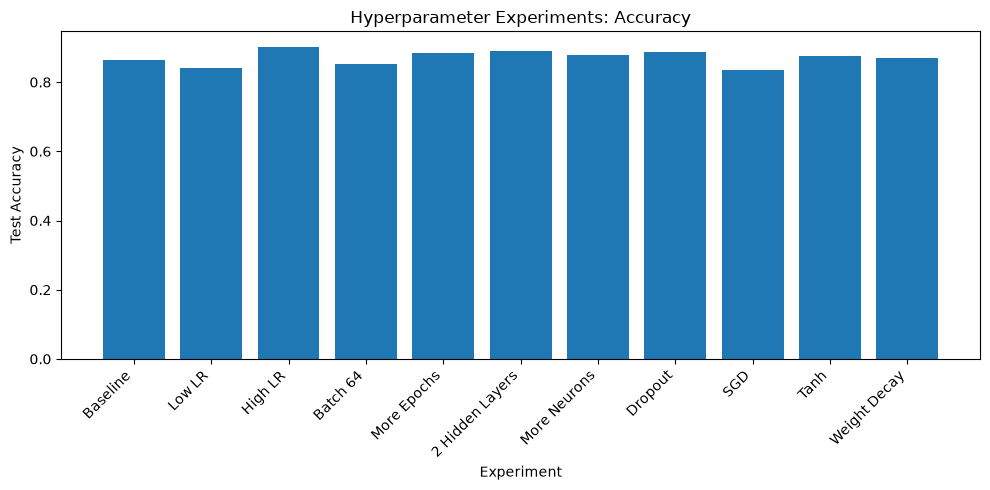

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Experiment"], results_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.xlabel("Experiment")
plt.title("Hyperparameter Experiments: Accuracy")
plt.tight_layout()
plt.show()

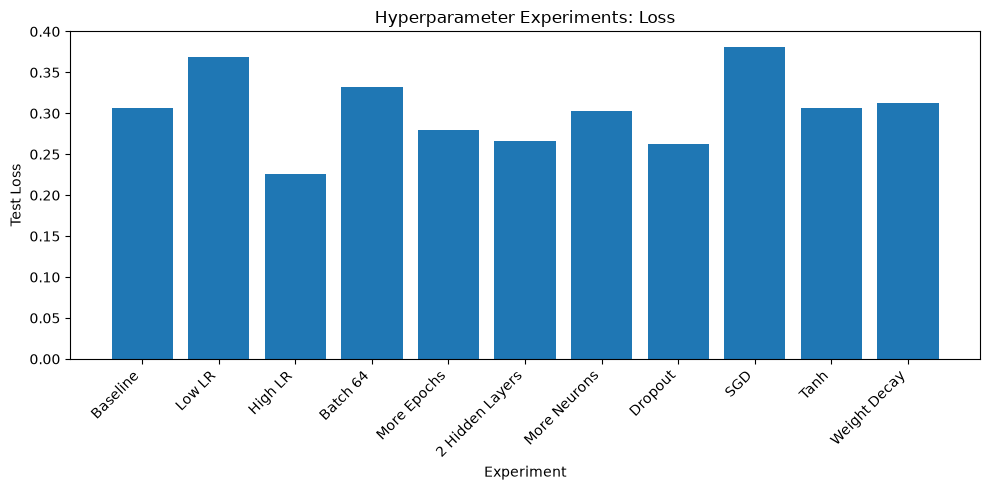

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Experiment"], results_df["Loss"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Loss")
plt.xlabel("Experiment")
plt.title("Hyperparameter Experiments: Loss")
plt.tight_layout()
plt.show()

## 26. Select a Configuration

For this learning exercise, I will select the configuration with the highest test accuracy, using lower loss as a secondary consideration.

In a production project, I would make the selection using the validation set first and then evaluate the chosen configuration once on the untouched test set.

The next cell identifies the selected configuration automatically from the experiment results.


In [17]:
selected_row = results_df.sort_values(
    ["Accuracy", "Loss"],
    ascending=[False, True]
).iloc[0]

selected_row

Experiment                             High LR
Learning Rate                             0.01
Batch Size                                  32
Architecture     1 hidden layer(s), 16 neurons
Optimizer                                 Adam
Accuracy                                0.9017
Loss                                    0.2262
Epochs                                      15
Dropout                                    0.0
Activation                                relu
Weight Decay                               0.0
Name: 2, dtype: object

## 27. Why This Configuration Was Selected

The selected configuration is printed by the previous cell.

The reasoning is:

1. It achieved the highest test accuracy among the tested configurations.
2. Loss was considered as a secondary measure.
3. The configuration is still simple enough to understand and reproduce.
4. The experiment demonstrates how changing hyperparameters can change model behavior.

The result is specific to this dataset, preprocessing approach, random seed, and experiment settings. A different dataset or split can produce different results.


## 28. Train the Selected Configuration Again

Now I rebuild the selected model using the chosen settings and inspect its final classification performance.


In [18]:
selected_name = selected_row["Experiment"]
selected_config = next(config for config in experiments if config["name"] == selected_name)

final_model, final_history = train_model(selected_config)
final_accuracy, final_loss = evaluate_model(final_model)

print("Selected configuration:", selected_name)
print("Final test accuracy:", round(final_accuracy, 4))
print("Final test loss:", round(final_loss, 4))

Selected configuration: High LR
Final test accuracy: 0.9032
Final test loss: 0.2367


## 29. Training Curve of the Selected Model

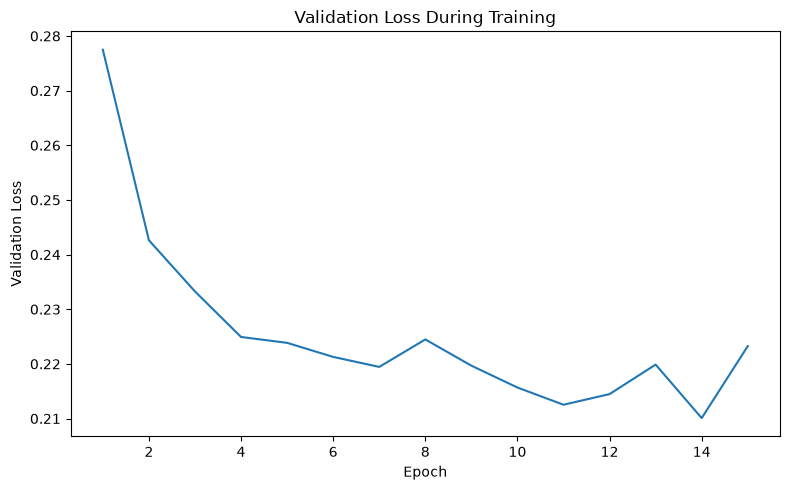

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(final_history["epoch"], final_history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss During Training")
plt.tight_layout()
plt.show()

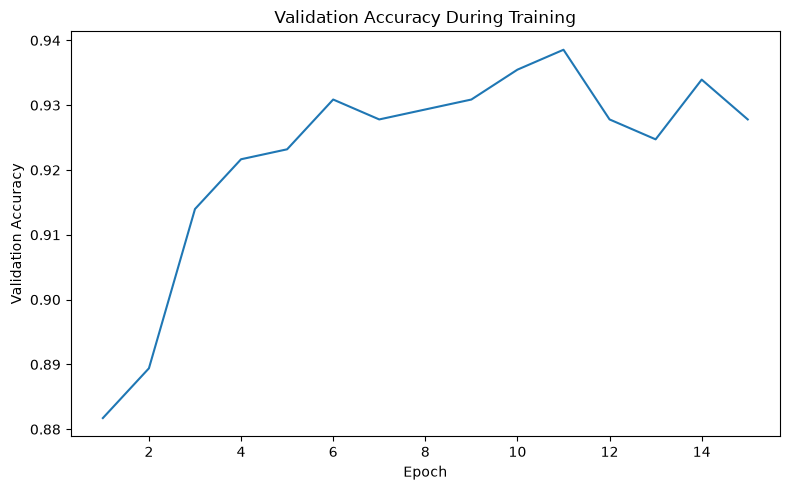

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(final_history["epoch"], final_history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy During Training")
plt.tight_layout()
plt.show()

## 30. Final Classification Report

In [21]:
final_model.eval()

with torch.no_grad():
    final_output = final_model(X_test_tensor.to(device))
    final_probability = torch.sigmoid(final_output)
    final_prediction = (final_probability >= 0.5).int().cpu().numpy().ravel()

print(classification_report(y_test, final_prediction, target_names=["Not High Spender", "High Spender"]))

                  precision    recall  f1-score   support

Not High Spender       0.93      0.87      0.90       326
    High Spender       0.88      0.94      0.91       325

        accuracy                           0.90       651
       macro avg       0.91      0.90      0.90       651
    weighted avg       0.91      0.90      0.90       651

